In [9]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("../data/features.csv", index_col = "Time_[s]")
targets = pd.read_csv("../data/targets.csv", index_col = False)
targets

,Experiment_ID,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
0,2,0.00,0.317461,0.337050,0.626034,0.344543
1,2,1.00,0.319825,0.363018,0.600159,0.372211
2,2,2.00,0.319035,0.401244,0.560835,0.412939
3,2,3.00,0.317768,0.438220,0.522651,0.452336
4,2,4.00,0.320230,0.465094,0.495879,0.480970
...,...,...,...,...,...,...
14558,318,41.00,0.641596,0.373375,0.680266,0.314326
14559,318,42.00,0.640550,0.372634,0.680719,0.313536
14560,318,43.00,0.640334,0.374073,0.679194,0.315070
14561,318,44.00,0.641037,0.377992,0.675413,0.319245


In [11]:

# Collect the 6th row's Main-axis value per experiment
selected = []
for exp_id, group in targets.groupby("Experiment_ID"):
    if len(group) > 6:  
        value = group.iloc[6]["Main-axis [mm]"]  # 6th row by position
    else:
        value = np.nan  # if experiment shorter than 7 rows
    selected.append([value])  # wrap in list → keeps (num_experiments, 1)

y = np.array(selected, dtype=float)

In [ ]:

# Collect the 6th row's Main-axis value per experiment
selected = []
for exp_id, group in targets.groupby("Experiment_ID"):
    if len(group) > 6:  
        value = group.iloc[6]["Main-axis [mm]"]  # 6th row by position
    else:
        value = np.nan  # if experiment shorter than 7 rows
    selected.append([value])  # wrap in list → keeps (num_experiments, 1)

y = np.array(selected, dtype=float)
y = np.array(y)
groups = []
max_len = df.groupby("Experiment_ID").size().max()  # longest experiment
num_features = df.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in df.groupby("Experiment_ID"):
    features = group.drop(columns=["Experiment_ID"]).values
    
    # Pad with NaN (or zeros) to match max_len
    padded = np.full((max_len, num_features), np.nan)  
    padded[:features.shape[0], :] = features
    groups.append(padded)

X = np.array(groups, dtype=float)

print("Shape:", X.shape)  

Shape: (315, 1743, 17)


Trained 10 trees, Validation MSE: 0.00109
Trained 20 trees, Validation MSE: 0.00109
Trained 30 trees, Validation MSE: 0.00108
Trained 40 trees, Validation MSE: 0.00109
Trained 50 trees, Validation MSE: 0.00108
Trained 60 trees, Validation MSE: 0.00106
Trained 70 trees, Validation MSE: 0.00106
Trained 80 trees, Validation MSE: 0.00110
Trained 90 trees, Validation MSE: 0.00117
Trained 100 trees, Validation MSE: 0.00119
Top feature-time pairs influencing the bending target:
Feature 6 at Timestep 282 Importance: 0.03079
Feature 16 at Timestep 639 Importance: 0.03047
Feature 6 at Timestep 265 Importance: 0.02784
Feature 9 at Timestep 600 Importance: 0.02743
Feature 7 at Timestep 1515 Importance: 0.02554
Feature 7 at Timestep 1600 Importance: 0.02500
Feature 6 at Timestep 384 Importance: 0.02469
Feature 7 at Timestep 1532 Importance: 0.02468
Feature 7 at Timestep 1566 Importance: 0.02326
Feature 13 at Timestep 1111 Importance: 0.02275


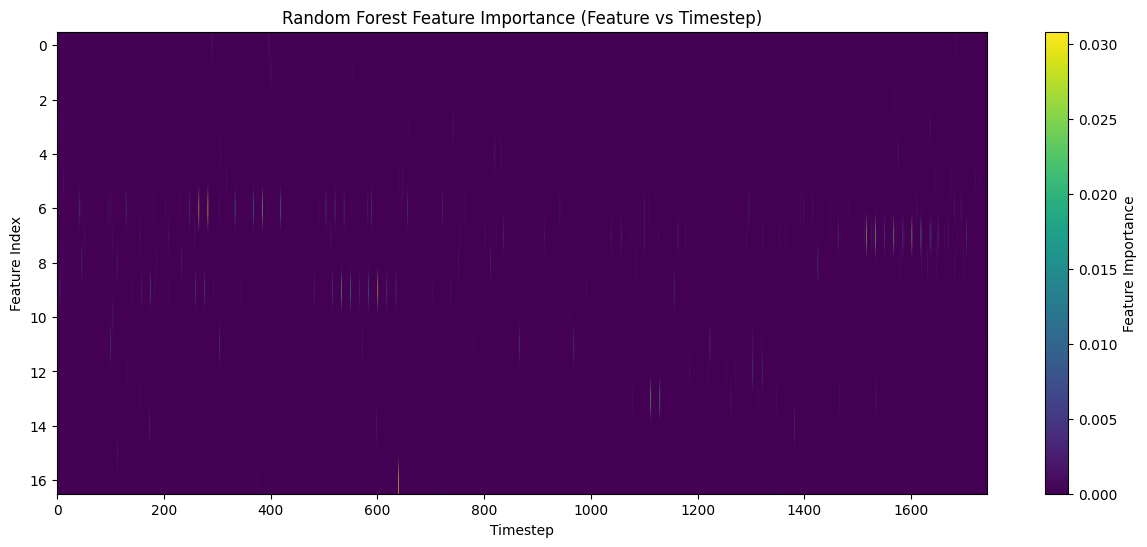

['random_forest_exp6.pkl']

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# ===============================
# Flatten data
# ===============================
n_samples, n_timesteps, n_features = X.shape
X_flat = X.reshape(n_samples, n_timesteps * n_features)

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_flat, y, test_size=0.2, random_state=42
)

# Flatten y to 1D
y_train = y_train.ravel()
y_val = y_val.ravel()


# ===============================
# Train Random Forest in chunks
# ===============================
n_estimators = 100
chunk_size = 10  # trees per batch
trained_trees = 0
model = RandomForestRegressor(
    n_estimators=chunk_size, warm_start=True, random_state=42, n_jobs=-1
)

while trained_trees < n_estimators:
    model.fit(X_train, y_train)
    trained_trees += chunk_size
    y_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    print(f"Trained {trained_trees} trees, Validation MSE: {mse:.5f}")
    model.n_estimators += chunk_size  # increment for next batch

# ===============================
# Feature importances
# ===============================
importances = model.feature_importances_
importances_reshaped = importances.reshape(n_features, n_timesteps)

top_n = 10
top_indices = importances.argsort()[::-1][:top_n]
print("Top feature-time pairs influencing the bending target:")
for idx in top_indices:
    feature_idx = idx // n_timesteps
    timestep_idx = idx % n_timesteps
    print(f"Feature {feature_idx} at Timestep {timestep_idx} Importance: {importances[idx]:.5f}")

# Heatmap
plt.figure(figsize=(15, 6))
plt.imshow(importances_reshaped, aspect='auto', cmap='viridis')
plt.colorbar(label="Feature Importance")
plt.xlabel("Timestep")
plt.ylabel("Feature Index")
plt.title("Random Forest Feature Importance (Feature vs Timestep)")
plt.show()

# Save model
import joblib
joblib.dump(model, "random_forest_exp6.pkl")


Prediction for the new sample: [0.46950196]
True value: [0.49561706]
Top feature-time pairs influencing the bending target:
Feature 6 at Timestep 282 Importance: 0.03079
Feature 16 at Timestep 639 Importance: 0.03047
Feature 6 at Timestep 265 Importance: 0.02784
Feature 9 at Timestep 600 Importance: 0.02743
Feature 7 at Timestep 1515 Importance: 0.02554
Feature 7 at Timestep 1600 Importance: 0.02500
Feature 6 at Timestep 384 Importance: 0.02469
Feature 7 at Timestep 1532 Importance: 0.02468
Feature 7 at Timestep 1566 Importance: 0.02326
Feature 13 at Timestep 1111 Importance: 0.02275


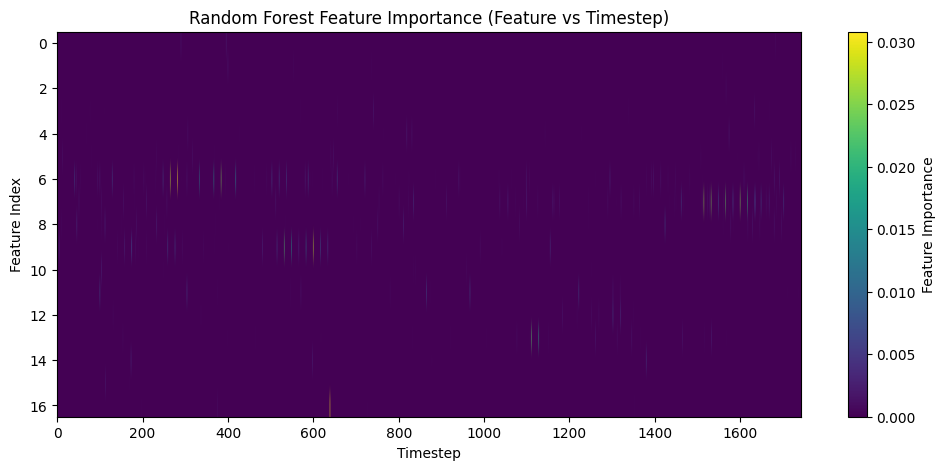

In [14]:
import joblib
import numpy as np

# ===============================
# Load the trained model
# ===============================
model = joblib.load("random_forest_exp6.pkl")

# ===============================
# Select a single sample and add new axis
# ===============================
X_new = X[0][np.newaxis, :, :]  # shape (1, n_timesteps, n_features)

# ===============================
# Flatten data to match training
# ===============================
n_samples_new, n_timesteps, n_features = X_new.shape
X_new_flat = X_new.reshape(n_samples_new, n_timesteps * n_features)

# ===============================
# Make prediction
# ===============================
y_new_pred = model.predict(X_new_flat)

print("Prediction for the new sample:", y_new_pred)
print("True value:", y[0])

# ===============================
# Optional: Feature importance for this prediction
# ===============================
importances = model.feature_importances_
importances_reshaped = importances.reshape(n_features, n_timesteps)
top_n = 10
top_indices = importances.argsort()[::-1][:top_n]
print("Top feature-time pairs influencing the bending target:")
for idx in top_indices:
    feature_idx = idx // n_timesteps
    timestep_idx = idx % n_timesteps
    print(f"Feature {feature_idx} at Timestep {timestep_idx} Importance: {importances[idx]:.5f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.imshow(importances_reshaped, aspect='auto', cmap='viridis')
plt.colorbar(label="Feature Importance")
plt.xlabel("Timestep")
plt.ylabel("Feature Index")
plt.title("Random Forest Feature Importance (Feature vs Timestep)")
plt.show()
